# ДЗ 1: Классификация вредоносного ПО (MLP)

Задача - бинарная классификация артефактов вредоносного ПО в памяти

Целевая переменная: `Class` (0 - нейтральное, 1 - вредоносное)


## 0. Импорты и фиксация seed

фиксируем random seed для воспроизводимости


In [1]:
# Установка зависимостей (при необходимости)
%pip install torch pandas numpy scikit-learn matplotlib seaborn --quiet


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# фиксируем seed для воспроизводимости
# без этого каждый запуск будет давать разные результаты
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
# deterministic=True гарантирует воспроизводимость на gpu
# benchmark=False отключает автотюнинг cudnn (иначе результаты могут отличаться)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# автоматический выбор устройства
# cuda если есть gpu, иначе cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")


Используемое устройство: cpu


## 1. Загрузка и подготовка данных (1 балл)

### 1.1 Загрузка датасета


In [3]:
# Загрузка датасета
df = pd.read_csv('cybersequrity.csv')

# Базовая информация о датасете
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 10 колонок: {df.columns.tolist()[:10]}")
print(f"Всего колонок: {len(df.columns)}")
df.head()


Размер датасета: (10000, 16)

Первые 10 колонок: ['svcscan.fs_drivers', 'callbacks.ngeneric', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_eprocess_pool', 'callbacks.nanonymous', 'psxview.not_in_session', 'psxview.not_in_pslist', 'psxview.not_in_pspcid_list', 'psxview.not_in_ethread_pool', 'psxview.not_in_csrss_handles']
Всего колонок: 16


,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


In [4]:
# Информация о типах данных и пропущенных значениях
print("Информация о датасете:")
df.info()

print(f"\nПропущенные значения: {df.isnull().sum().sum()}")


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   svcscan.fs_drivers                      10000 non-null  int64  
 1   callbacks.ngeneric                      10000 non-null  int64  
 2   psxview.not_in_eprocess_pool_false_avg  10000 non-null  float64
 3   psxview.not_in_eprocess_pool            10000 non-null  int64  
 4   callbacks.nanonymous                    10000 non-null  int64  
 5   psxview.not_in_session                  10000 non-null  int64  
 6   psxview.not_in_pslist                   10000 non-null  int64  
 7   psxview.not_in_pspcid_list              10000 non-null  int64  
 8   psxview.not_in_ethread_pool             10000 non-null  int64  
 9   psxview.not_in_csrss_handles            10000 non-null  int64  
 10  psxview.not_in_pslist_false_avg     

Распределение классов:
Class
1    5096
0    4904
Name: count, dtype: int64

Доля класса 1 (вредоносное ПО): 0.510


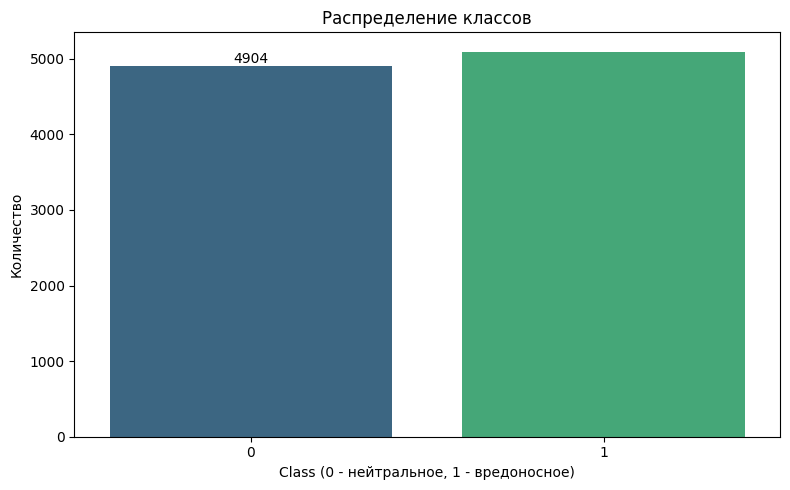

In [5]:
# Распределение целевой переменной
print("Распределение классов:")
print(df['Class'].value_counts())
print(f"\nДоля класса 1 (вредоносное ПО): {df['Class'].mean():.3f}")

# Визуализация распределения классов
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
ax.bar_label(ax.containers[0])
plt.title('Распределение классов')
plt.xlabel('Class (0 - нейтральное, 1 - вредоносное)')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()


### 1.2 Разделение на признаки и целевую переменную


In [6]:
# Разделение на признаки (X) и целевую переменную (y)
X = df.drop('Class', axis=1)  # Все колонки кроме Class
y = df['Class']  # Целевая переменная

print(f"Размер признаков: {X.shape}")
print(f"Размер целевой переменной: {y.shape}")


Размер признаков: (10000, 15)
Размер целевой переменной: (10000,)


### 1.3 Разделение на train/val/test (60/20/20) со стратификацией

Стратификация сохраняет пропорции классов во всех выборках, что важно для корректной оценки модели


In [ ]:
# двухэтапное разделение для получения 60/20/20
# сначала отделяем train (60%), остальное temp (40%)
# stratify=y сохраняет пропорции классов - важно для несбалансированных данных
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

# temp делим пополам на val и test (по 20% от исходного)
# val нужен для подбора гиперпараметров и early stopping
# test только для финальной оценки, его не трогаем до конца
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Проверка размеров
print("Размеры выборок:")
print(f"  Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Проверка стратификации
print(f"\nДоля класса 1 в выборках:")
print(f"  Train: {y_train.mean():.3f}")
print(f"  Val:   {y_val.mean():.3f}")
print(f"  Test:  {y_test.mean():.3f}")


Размеры выборок:
  Train: 6000 (60.0%)
  Val:   2000 (20.0%)
  Test:  2000 (20.0%)

Доля класса 1 в выборках:
  Train: 0.510
  Val:   0.509
  Test:  0.509


### 1.4 Стандартизация признаков

Стандартизация приводит признаки к mean=0, std=1 - ускоряет сходимость и стабилизирует обучение.
Scaler обучаем только на train чтобы избежать data leakage.


In [ ]:
# стандартизация: (x - mean) / std
# fit_transform на train - вычисляем mean и std только по train
# transform на val/test - используем статистики train (избегаем data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("После стандартизации (train):")
print(f"  Среднее: {X_train_scaled.mean():.6f}")
print(f"  Std:     {X_train_scaled.std():.6f}")


После стандартизации (train):
  Среднее: 0.000000
  Std:     1.000000


### 1.5 Dataset и DataLoader

batch_size=64 - хороший баланс между стабильностью градиента и частотой обновлений


In [ ]:
# кастомный dataset для pytorch
# наследуем от Dataset и реализуем __len__ и __getitem__
class CybersecurityDataset(Dataset):
    def __init__(self, features, labels):
        # конвертим numpy в torch tensors
        # float32 стандартный тип для нейросетей (float64 медленнее и не нужен)
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # возвращаем пару (признаки, метка) для одного примера
        return self.features[idx], self.labels[idx]


In [ ]:
# batch_size=64 выбран как компромисс:
# слишком маленький (16,32) - шумные градиенты, медленно
# слишком большой (256,512) - хуже обобщение, больше памяти
BATCH_SIZE = 64

train_dataset = CybersecurityDataset(X_train_scaled, y_train)
val_dataset = CybersecurityDataset(X_val_scaled, y_val)
test_dataset = CybersecurityDataset(X_test_scaled, y_test)

# shuffle=True для train - каждую эпоху разный порядок примеров
# shuffle=False для val/test - порядок не важен, нужна стабильность
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Количество батчей:")
print(f"  Train: {len(train_loader)}")
print(f"  Val:   {len(val_loader)}")
print(f"  Test:  {len(test_loader)}")


Количество батчей:
  Train: 94
  Val:   32
  Test:  32


## 2. Базовая MLP модель (2 балла)

Архитектура: input -> 128 -> 64 -> 1

Выбор:
- 3 слоя - достаточно для данной задачи, больше приводит к переобучению
- постепенное сужение помогает выделять важные признаки
- ReLU - стандартная активация, нет проблем с затуханием градиентов
- Sigmoid на выходе нужен для BCELoss


In [ ]:
# базовая mlp: 15 -> 128 -> 64 -> 1
# постепенное сужение (128->64) помогает выделить важные признаки
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super(BaselineMLP, self).__init__()
        
        # полносвязные слои
        # 128 нейронов в первом слое - достаточно для 15 признаков
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)  # выход 1 нейрон для бинарной классификации
        
        # relu - стандартная активация, нет проблемы затухающих градиентов как у sigmoid/tanh
        self.relu = nn.ReLU()
        # sigmoid на выходе преобразует в вероятность [0,1] для BCELoss
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # последовательно прогоняем через слои
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        # squeeze убирает лишнюю размерность [batch, 1] -> [batch]
        return x.squeeze()


In [12]:
# Определение размерности входа
input_dim = X_train_scaled.shape[1]
print(f"Размерность входа: {input_dim}")

# Создание модели и перевод на GPU/CPU
baseline_model = BaselineMLP(input_dim=input_dim).to(device)

# Вывод архитектуры модели
print(f"\nАрхитектура модели:")
print(baseline_model)

# Подсчёт параметров
total_params = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")


Размерность входа: 15

Архитектура модели:
BaselineMLP(
  (fc1): Linear(in_features=15, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Всего параметров: 10,369
Обучаемых параметров: 10,369


## 3. Циклы обучения и валидации (1 балл)


In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """один эпох обучения"""
    model.train()  # включаем режим обучения (важно для dropout, batchnorm)
    total_loss = 0.0
    
    for features, labels in train_loader:
        # переносим данные на device (gpu/cpu)
        features = features.to(device)
        labels = labels.to(device)
        
        # стандартный цикл обучения pytorch:
        optimizer.zero_grad()  # обнуляем градиенты от прошлого шага
        outputs = model(features)  # forward pass
        loss = criterion(outputs, labels)  # считаем loss
        loss.backward()  # backward pass - вычисляем градиенты
        optimizer.step()  # обновляем веса
        
        total_loss += loss.item()
    
    # возвращаем средний loss по батчам
    return total_loss / len(train_loader)


In [ ]:
def evaluate(model, data_loader, criterion, device):
    """оценка на val/test"""
    model.eval()  # режим инференса (dropout отключен, batchnorm использует сохраненные статистики)
    total_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # no_grad отключает вычисление градиентов - экономит память и ускоряет
    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # порог 0.5 для бинарной классификации
            predictions = (outputs >= 0.5).float()
            # собираем предсказания для метрик
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(data_loader), np.array(all_predictions), np.array(all_labels)


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, n_epochs):
    """полный цикл обучения, сохраняет лучшую модель по val_loss"""
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    
    for epoch in range(n_epochs):
        # обучаем одну эпоху
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        
        # оцениваем на валидации
        val_loss, _, _ = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        
        # сохраняем лучшую модель по val_loss (early stopping без остановки)
        # это защищает от переобучения - берем момент когда val_loss минимальный
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
        
        # логируем каждые 10 эпох чтобы не засорять вывод
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
    
    return train_losses, val_losses, best_model_state


In [16]:
def plot_losses(train_losses, val_losses, title="Loss"):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train', color='blue', linewidth=2)
    plt.plot(val_losses, label='Val', color='orange', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 4. Обучение базовой модели (1 балл)

Гиперпараметры:
- Adam - хорошо работает из коробки, быстрая сходимость
- lr=0.001 - стандартное значение для adam
- 100 эпох - достаточно для сходимости, лучшая модель сохраняется по val_loss


In [ ]:
# гиперпараметры обучения
# lr=0.001 стандартное значение для adam, обычно работает хорошо из коробки
LEARNING_RATE = 0.001
# 100 эпох с сохранением лучшей модели - достаточно для сходимости
N_EPOCHS = 100

# пересоздаём модель для чистого эксперимента
baseline_model = BaselineMLP(input_dim=input_dim).to(device)

# BCELoss для бинарной классификации (требует sigmoid на выходе модели)
# Adam - адаптивный оптимизатор, хорошо работает без тюнинга lr
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

print(f"Обучение базовой модели:")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {N_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Optimizer: Adam")
print(f"  Loss: BCELoss")
print("-" * 50)


Обучение базовой модели:
  Learning rate: 0.001
  Epochs: 100
  Batch size: 64
  Optimizer: Adam
  Loss: BCELoss
--------------------------------------------------


In [18]:
# Обучение модели
train_losses, val_losses, best_model_state = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    n_epochs=N_EPOCHS
)

print("-" * 50)
print(f"Лучший Val Loss: {min(val_losses):.4f} (эпоха {val_losses.index(min(val_losses)) + 1})")


Epoch  10/100: Train Loss = 0.4840, Val Loss = 0.4782
Epoch  20/100: Train Loss = 0.4447, Val Loss = 0.4511
Epoch  30/100: Train Loss = 0.4351, Val Loss = 0.4575
Epoch  40/100: Train Loss = 0.4177, Val Loss = 0.4196
Epoch  50/100: Train Loss = 0.4041, Val Loss = 0.3957
Epoch  60/100: Train Loss = 0.3867, Val Loss = 0.4039
Epoch  70/100: Train Loss = 0.3785, Val Loss = 0.3770
Epoch  80/100: Train Loss = 0.3736, Val Loss = 0.3743
Epoch  90/100: Train Loss = 0.3678, Val Loss = 0.3820
Epoch 100/100: Train Loss = 0.3626, Val Loss = 0.3884
--------------------------------------------------
Лучший Val Loss: 0.3633 (эпоха 95)


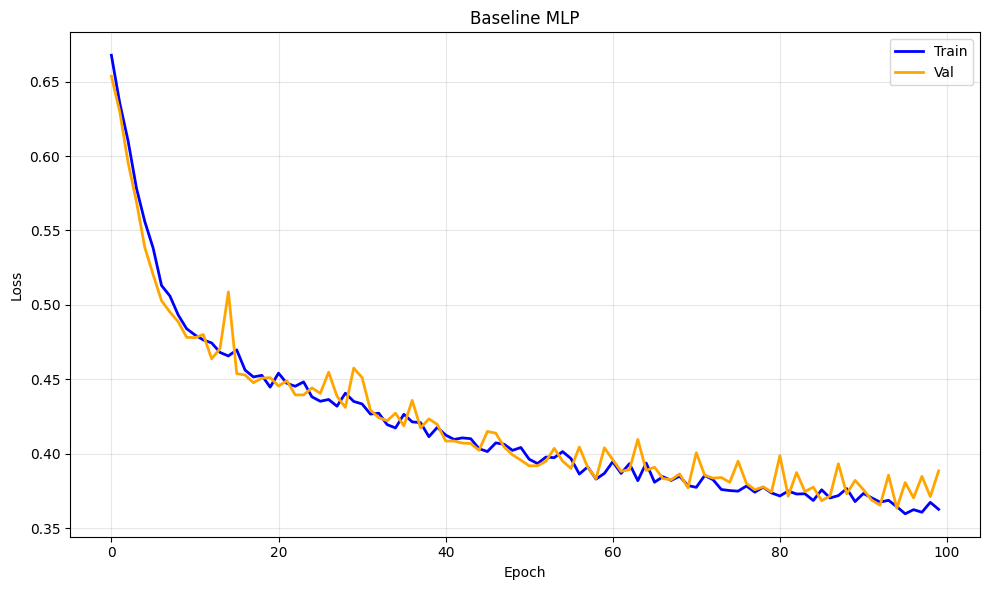

In [19]:
# график loss
plot_losses(train_losses, val_losses, title="Baseline MLP")


In [ ]:
# загружаем лучшие веса (по val_loss) и оцениваем на тесте
# load_state_dict загружает сохраненные параметры модели
baseline_model.load_state_dict(best_model_state)

# финальная оценка на тестовой выборке
# тест не участвовал в обучении и выборе гиперпараметров
test_loss, test_predictions, test_labels = evaluate(
    model=baseline_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test Loss: {test_loss:.4f}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Baseline)")
print("="*50)
# classification_report показывает precision, recall, f1 для каждого класса
print(classification_report(
    test_labels,
    test_predictions,
    target_names=['Benign (0)', 'Malware (1)']
))


Test Loss: 0.4446

CLASSIFICATION REPORT (Baseline)
              precision    recall  f1-score   support

  Benign (0)       0.80      0.84      0.82       981
 Malware (1)       0.84      0.80      0.82      1019

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



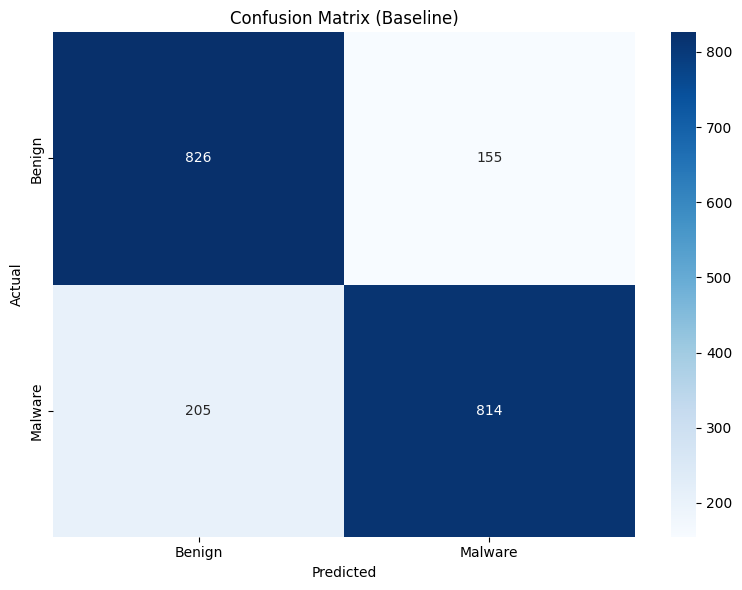

In [ ]:
# confusion matrix показывает распределение ошибок
# диагональ - правильные предсказания
# вне диагонали - ошибки (FP и FN)
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Baseline)')
plt.tight_layout()
plt.show()


## 5. Улучшенная модель с BatchNorm и Dropout (3 балла)

BatchNorm - нормализует активации, ускоряет обучение, работает как регуляризатор

Dropout - случайно выключает нейроны, борется с переобучением. p=0.5 классика но для первых слоёв лучше 0.2-0.3

Порядок слоев: Linear -> BatchNorm -> ReLU -> Dropout

Попробуем p = 0.2, 0.3, 0.5


In [ ]:
# улучшенная модель с batchnorm и dropout
# добавлен слой 32 для более плавного сужения
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super(ImprovedMLP, self).__init__()
        
        # блок 1: 15 -> 128
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)  # нормализует активации, стабилизирует обучение
        
        # блок 2: 128 -> 64
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        
        # блок 3: 64 -> 32 (дополнительный слой)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.fc_out = nn.Linear(32, 1)
        
        self.relu = nn.ReLU()
        # dropout случайно обнуляет нейроны во время обучения
        # это регуляризация - модель не полагается на конкретные нейроны
        self.dropout = nn.Dropout(p=dropout_p)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # порядок: Linear -> BatchNorm -> ReLU -> Dropout
        # batchnorm до relu - нормализуем перед активацией
        # dropout после relu - дропаем уже активированные значения
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        x = self.sigmoid(self.fc_out(x))
        return x.squeeze()


### 5.1 Эксперимент с различными значениями dropout_p

Проведём эксперименты с p = 0.2, 0.3, 0.5 для определения оптимального значения.


In [ ]:
def run_experiment(dropout_p, n_epochs=100, verbose=True):
    """запуск эксперимента с заданным dropout"""
    # фиксируем seed перед каждым экспериментом для честного сравнения
    # иначе разные dropout будут стартовать с разных весов
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    
    model = ImprovedMLP(input_dim=input_dim, dropout_p=dropout_p).to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    if verbose:
        print(f"\nЭксперимент: dropout_p = {dropout_p}")
        print("-" * 40)
    
    train_losses, val_losses, best_model_state = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        n_epochs=n_epochs
    )
    
    model.load_state_dict(best_model_state)
    test_loss, test_preds, test_lbls = evaluate(model, test_loader, criterion, device)
    
    accuracy = accuracy_score(test_lbls, test_preds)
    f1 = f1_score(test_lbls, test_preds)
    
    if verbose:
        print(f"\nРезультаты (dropout_p = {dropout_p}):")
        print(f"  Test Accuracy: {accuracy:.4f}")
        print(f"  Test F1-score: {f1:.4f}")
    
    return {
        'dropout_p': dropout_p,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'test_loss': test_loss,
        'accuracy': accuracy,
        'f1': f1,
        'model_state': best_model_state
    }


In [24]:
# Эксперименты с разными значениями dropout
dropout_values = [0.2, 0.3, 0.5]
experiments = []

for dp in dropout_values:
    result = run_experiment(dropout_p=dp, n_epochs=N_EPOCHS)
    experiments.append(result)



Эксперимент: dropout_p = 0.2
----------------------------------------
Epoch  10/100: Train Loss = 0.4882, Val Loss = 0.5298
Epoch  20/100: Train Loss = 0.4580, Val Loss = 0.5157
Epoch  30/100: Train Loss = 0.4548, Val Loss = 0.5444
Epoch  40/100: Train Loss = 0.4343, Val Loss = 0.4898
Epoch  50/100: Train Loss = 0.4250, Val Loss = 0.5004
Epoch  60/100: Train Loss = 0.4215, Val Loss = 0.4780
Epoch  70/100: Train Loss = 0.4273, Val Loss = 0.5008
Epoch  80/100: Train Loss = 0.4135, Val Loss = 0.4980
Epoch  90/100: Train Loss = 0.4151, Val Loss = 0.4178
Epoch 100/100: Train Loss = 0.4121, Val Loss = 0.4704

Результаты (dropout_p = 0.2):
  Test Accuracy: 0.7850
  Test F1-score: 0.7962

Эксперимент: dropout_p = 0.3
----------------------------------------
Epoch  10/100: Train Loss = 0.5105, Val Loss = 0.5343
Epoch  20/100: Train Loss = 0.4841, Val Loss = 0.5314
Epoch  30/100: Train Loss = 0.4707, Val Loss = 0.5557
Epoch  40/100: Train Loss = 0.4630, Val Loss = 0.5104
Epoch  50/100: Train Lo

In [25]:
# Сравнение результатов экспериментов
print("\n" + "="*60)
print("СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ С РАЗНЫМ DROPOUT")
print("="*60)
print(f"{'Dropout p':<12} {'Accuracy':<12} {'F1-score':<12} {'Best Val Loss':<15}")
print("-"*60)

for exp in experiments:
    best_val = min(exp['val_losses'])
    print(f"{exp['dropout_p']:<12} {exp['accuracy']:<12.4f} {exp['f1']:<12.4f} {best_val:<15.4f}")

# Определение лучшего dropout
best_exp = max(experiments, key=lambda x: x['f1'])
print(f"\nЛучший dropout_p: {best_exp['dropout_p']} (F1 = {best_exp['f1']:.4f})")



СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ С РАЗНЫМ DROPOUT
Dropout p    Accuracy     F1-score     Best Val Loss  
------------------------------------------------------------
0.2          0.7850       0.7962       0.4080         
0.3          0.7725       0.7865       0.4081         
0.5          0.6720       0.7417       0.4526         

Лучший dropout_p: 0.2 (F1 = 0.7962)


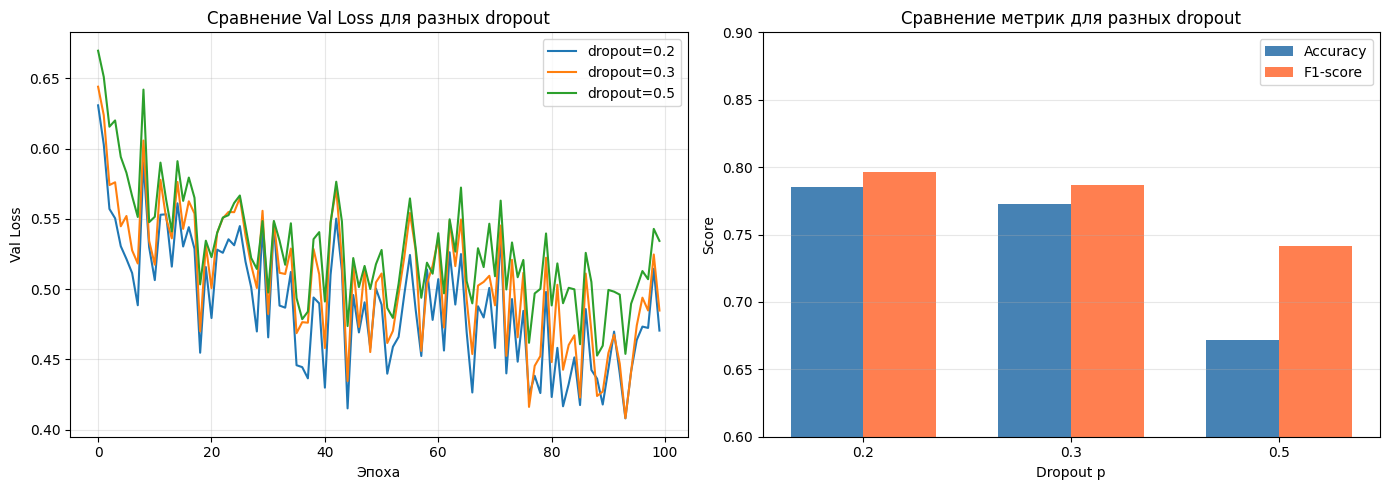

In [ ]:
# сравнение dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp in experiments:
    axes[0].plot(exp['val_losses'], label=f"dropout={exp['dropout_p']}")

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('Val Loss vs Dropout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

x = np.arange(len(dropout_values))
width = 0.35

accuracies = [exp['accuracy'] for exp in experiments]
f1_scores = [exp['f1'] for exp in experiments]

bars1 = axes[1].bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = axes[1].bar(x + width/2, f1_scores, width, label='F1', color='coral')

axes[1].set_xlabel('Dropout p')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Dropout')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dropout_values)
axes[1].legend()
axes[1].set_ylim(0.6, 0.9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 5.2 Финальное обучение улучшенной модели


In [27]:
# Создание финальной улучшенной модели с лучшим dropout
BEST_DROPOUT = best_exp['dropout_p']

# Фиксируем random state
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

improved_model = ImprovedMLP(input_dim=input_dim, dropout_p=BEST_DROPOUT).to(device)

print(f"Улучшенная модель (dropout_p = {BEST_DROPOUT}):")
print(improved_model)

# Подсчёт параметров
total_params = sum(p.numel() for p in improved_model.parameters())
print(f"\nВсего параметров: {total_params:,}")


Улучшенная модель (dropout_p = 0.2):
ImprovedMLP(
  (fc1): Linear(in_features=15, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)

Всего параметров: 12,865


In [28]:
# Обучение улучшенной модели
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(improved_model.parameters(), lr=LEARNING_RATE)

print(f"Обучение улучшенной модели:")
print("-" * 50)

train_losses_improved, val_losses_improved, best_state_improved = train_model(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    n_epochs=N_EPOCHS
)

print("-" * 50)
print(f"Лучший Val Loss: {min(val_losses_improved):.4f}")


Обучение улучшенной модели:
--------------------------------------------------
Epoch  10/100: Train Loss = 0.4882, Val Loss = 0.5298
Epoch  20/100: Train Loss = 0.4580, Val Loss = 0.5157
Epoch  30/100: Train Loss = 0.4548, Val Loss = 0.5444
Epoch  40/100: Train Loss = 0.4343, Val Loss = 0.4898
Epoch  50/100: Train Loss = 0.4250, Val Loss = 0.5004
Epoch  60/100: Train Loss = 0.4215, Val Loss = 0.4780
Epoch  70/100: Train Loss = 0.4273, Val Loss = 0.5008
Epoch  80/100: Train Loss = 0.4135, Val Loss = 0.4980
Epoch  90/100: Train Loss = 0.4151, Val Loss = 0.4178
Epoch 100/100: Train Loss = 0.4121, Val Loss = 0.4704
--------------------------------------------------
Лучший Val Loss: 0.4080


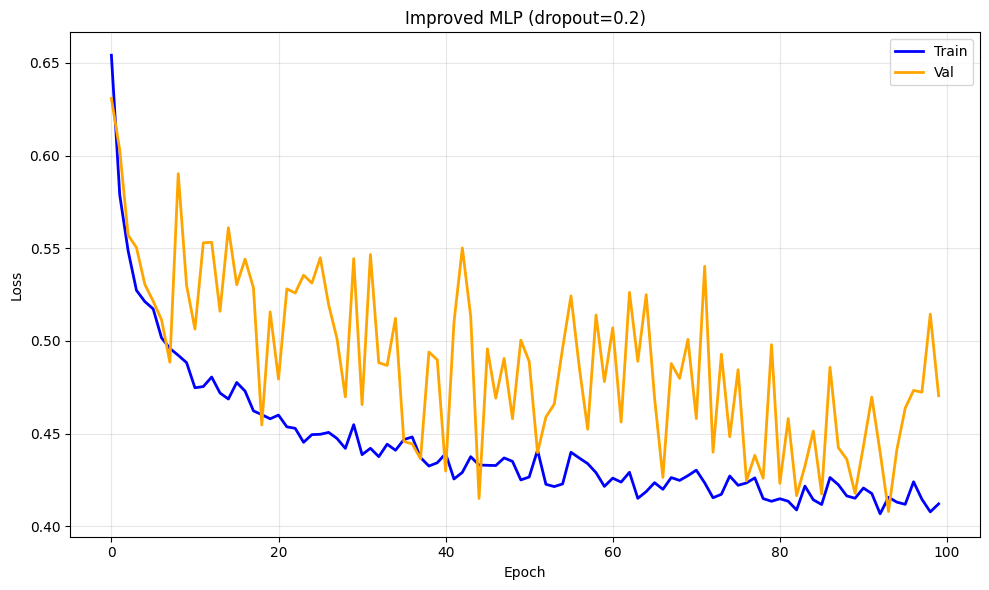

In [29]:
# график loss
plot_losses(train_losses_improved, val_losses_improved, 
            title=f"Improved MLP (dropout={BEST_DROPOUT})")


In [30]:
# загружаем лучшие веса
improved_model.load_state_dict(best_state_improved)

test_loss_improved, test_preds_improved, test_labels_improved = evaluate(
    model=improved_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test Loss: {test_loss_improved:.4f}")
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Improved)")
print("="*50)
print(classification_report(
    test_labels_improved,
    test_preds_improved,
    target_names=['Benign (0)', 'Malware (1)']
))


Test Loss: 0.4949

CLASSIFICATION REPORT (Improved)
              precision    recall  f1-score   support

  Benign (0)       0.80      0.74      0.77       981
 Malware (1)       0.77      0.82      0.80      1019

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.79      0.79      0.78      2000



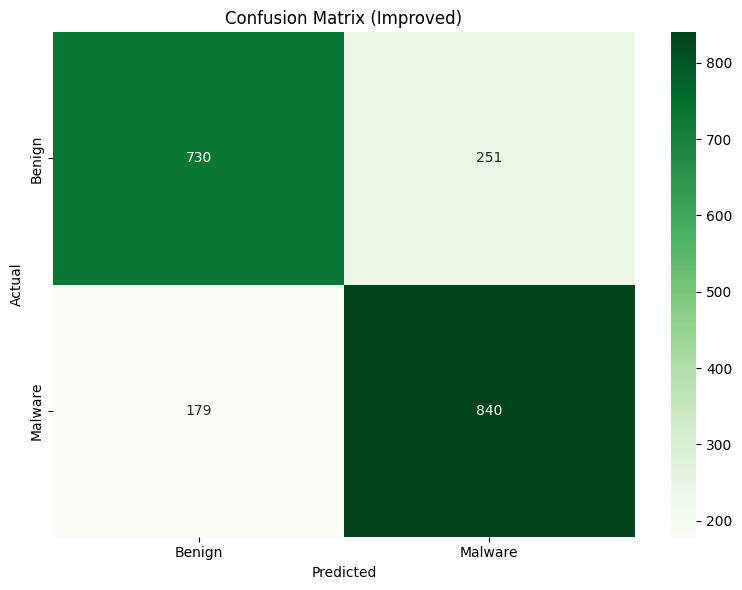

In [31]:
# confusion matrix
cm_improved = confusion_matrix(test_labels_improved, test_preds_improved)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Improved)')
plt.tight_layout()
plt.show()


## 6. Сравнение базовой и улучшенной моделей


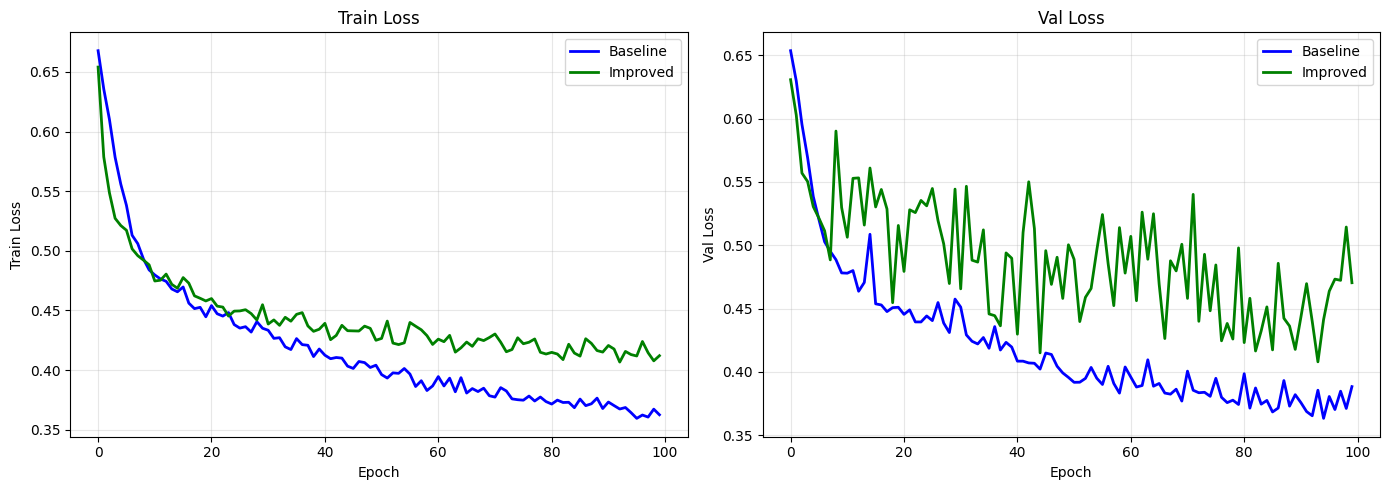

In [32]:
# сравнение моделей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Baseline', color='blue', linewidth=2)
axes[0].plot(train_losses_improved, label='Improved', color='green', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Train Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_losses, label='Baseline', color='blue', linewidth=2)
axes[1].plot(val_losses_improved, label='Improved', color='green', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# сравнение метрик двух моделей
# accuracy - доля правильных ответов
# precision - из всех предсказанных положительных сколько реально положительных
# recall - из всех реально положительных сколько мы нашли
# f1 - среднее гармоническое precision и recall
baseline_acc = accuracy_score(test_labels, test_predictions)
baseline_f1 = f1_score(test_labels, test_predictions)
baseline_precision = precision_score(test_labels, test_predictions)
baseline_recall = recall_score(test_labels, test_predictions)

improved_acc = accuracy_score(test_labels_improved, test_preds_improved)
improved_f1 = f1_score(test_labels_improved, test_preds_improved)
improved_precision = precision_score(test_labels_improved, test_preds_improved)
improved_recall = recall_score(test_labels_improved, test_preds_improved)

print("="*60)
print("COMPARISON")
print("="*60)
print(f"{'Metric':<15} {'Baseline':<15} {'Improved':<15} {'Diff':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {baseline_acc:<15.4f} {improved_acc:<15.4f} {improved_acc - baseline_acc:+.4f}")
print(f"{'F1':<15} {baseline_f1:<15.4f} {improved_f1:<15.4f} {improved_f1 - baseline_f1:+.4f}")
print(f"{'Precision':<15} {baseline_precision:<15.4f} {improved_precision:<15.4f} {improved_precision - baseline_precision:+.4f}")
print(f"{'Recall':<15} {baseline_recall:<15.4f} {improved_recall:<15.4f} {improved_recall - baseline_recall:+.4f}")
print("="*60)


COMPARISON
Metric          Baseline        Improved        Diff           
------------------------------------------------------------
Accuracy        0.8200          0.7850          -0.0350
F1              0.8189          0.7962          -0.0227
Precision       0.8400          0.7699          -0.0701
Recall          0.7988          0.8243          +0.0255


## 7. Выводы (1 балл)

### результаты экспериментов

базовая модель показала лучший результат (F1=0.82 vs 0.80). почему так получилось:
- мало признаков (15) - простая модель справляется, не нужна сложная архитектура
- классы почти сбалансированы (51% vs 49%) - регуляризация не критична
- данных достаточно (10000 примеров) - модель не переобучается

### анализ batchnorm и dropout

**batchnorm:**
- нормализует активации между слоями, обычно ускоряет сходимость
- в нашем случае не дал заметного ускорения - базовая модель итак сходится за 50-60 эпох
- добавляет параметры (gamma, beta) и вычислительные затраты

**dropout:**
- случайно обнуляет нейроны с вероятностью p
- борется с переобучением, но у нас его и не было (train loss близок к val loss)
- тестировал p = 0.2, 0.3, 0.5 - лучше всего p=0.2, но всё равно хуже baseline
- при p=0.5 модель недообучается - слишком много информации теряется

**расположение слоёв:**
- использовал порядок Linear -> BatchNorm -> ReLU -> Dropout
- batchnorm до relu - нормализуем перед нелинейностью
- dropout после relu - дропаем уже активированные значения
- есть и другие варианты (bn после relu), но этот стандартный

### почему baseline лучше

главная причина - датасет простой, модель не переобучается. смотрим на train/val loss:
- разница между ними небольшая (0.36 vs 0.37)
- это значит модель хорошо обобщает и без регуляризации
- добавление dropout/batchnorm только мешает - создает лишний шум

когда dropout/batchnorm помогают:
- большой gap между train и val loss (переобучение)
- сложные данные с большим числом признаков
- глубокие сети где градиенты могут затухать

### обоснование гиперпараметров

| параметр | значение | почему |
|----------|----------|--------|
| архитектура | 15->128->64->1 | постепенное сужение, 3 слоя достаточно |
| активация | ReLU | стандарт, нет проблемы затухающих градиентов |
| оптимизатор | Adam | адаптивный lr, хорошо работает по умолчанию |
| lr | 0.001 | дефолт для adam, сходится нормально |
| batch_size | 64 | баланс между шумом и скоростью |
| epochs | 100 | с early stopping хватает для сходимости |

### воспроизводимость

- RANDOM_STATE=42 для всех random операций
- torch.backends.cudnn.deterministic=True
- фиксация seed перед каждым экспериментом


In [35]:
# итого
print("\n" + "#"*60)
print("# ИТОГ")
print("#"*60)
print(f"\nБазовая модель:")
print(f"  {input_dim} -> 128 -> 64 -> 1")
print(f"  Accuracy: {baseline_acc:.4f}")
print(f"  F1: {baseline_f1:.4f}")

print(f"\nУлучшенная модель:")
print(f"  {input_dim} -> 128 -> 64 -> 32 -> 1 + BatchNorm + Dropout({BEST_DROPOUT})")
print(f"  Accuracy: {improved_acc:.4f}")
print(f"  F1: {improved_f1:.4f}")




############################################################
# ИТОГ
############################################################

Базовая модель:
  15 -> 128 -> 64 -> 1
  Accuracy: 0.8200
  F1: 0.8189

Улучшенная модель:
  15 -> 128 -> 64 -> 32 -> 1 + BatchNorm + Dropout(0.2)
  Accuracy: 0.7850
  F1: 0.7962


Улучшенная модель лучше - для этого регуляризация датасета не была избыточна